# Khử sương bằng Dark Channel Prior (DCP)

Cài đặt DCP cơ bản theo các bước: tính dark channel, ước lượng ánh sáng khí quyển $A$, ước lượng bản đồ truyền dẫn $t(x)$ và khôi phục ảnh không sương.

Ảnh: E:\repoE\VDT_GD2\dataset\I-HAZE\train\hazy\ih1_hazy.png


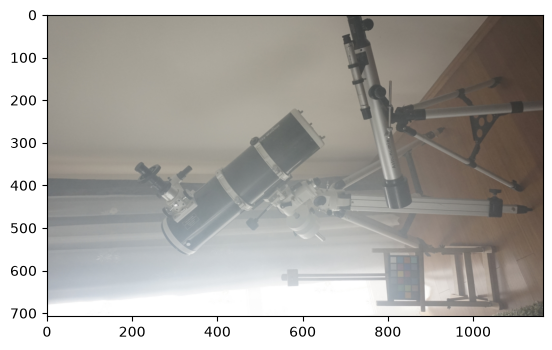

Kích thước: (708, 1164, 3)


In [15]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


# Hỗ trợ chạy notebook từ thư mục gốc hoặc từ thư mục solution.
image_candidates = [
    Path('../dataset/I-HAZE/train/hazy/ih1_hazy.png'),
    Path('dataset/I-HAZE/train/hazy/ih1_hazy.png'),
]
image_path = next((path for path in image_candidates if path.exists()), None)
if image_path is None:
    raise FileNotFoundError('Không tìm thấy ảnh .')

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f'Không thể đọc ảnh: {image_path}')

# OpenCV đọc ảnh theo BGR; chuyển sang RGB và chuẩn hóa về [0, 1].
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image = image_rgb.astype(np.float64) / 255.0

print(f'Ảnh: {image_path.resolve()}')
plt.imshow(image)
plt.show()
print(f'Kích thước: {image.shape}')

## Các hàm của DCP cơ bản

Với ảnh có sương $I(x) = J(x)t(x) + A(1-t(x))$, DCP giả định trong phần lớn vùng không phải bầu trời, ít nhất một kênh màu của ảnh không sương có giá trị rất nhỏ.

In [16]:
def dark_channel(image, patch_size=15):
    """Tính dark channel bằng phép min trên kênh màu và cửa sổ cục bộ."""
    if patch_size < 1 or patch_size % 2 == 0:
        raise ValueError('patch_size phải là số nguyên dương và lẻ.')

    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (patch_size, patch_size)
    )
    return cv2.erode(min_channel, kernel)


def estimate_atmospheric_light(image, dark, top_percent=0.001):
    """Ước lượng A từ top_percent pixel sáng nhất trong dark channel."""
    if not 0 < top_percent <= 1:
        raise ValueError('top_percent phải nằm trong khoảng (0, 1].')

    flat_image = image.reshape(-1, 3)
    flat_dark = dark.ravel()
    number_of_pixels = max(int(flat_dark.size * top_percent), 1)
    brightest_indices = np.argpartition(
        flat_dark, -number_of_pixels
    )[-number_of_pixels:]

    # Lấy trung bình để giảm ảnh hưởng của nhiễu hoặc một pixel bão hòa.
    atmospheric_light = np.mean(flat_image[brightest_indices], axis=0)
    return np.maximum(atmospheric_light, 1e-6)


def estimate_transmission(image, atmospheric_light, patch_size=15, omega=0.95):
    """Ước lượng transmission: t(x) = 1 - omega * dark(I(x) / A)."""
    normalized_image = image / atmospheric_light.reshape(1, 1, 3)
    transmission = 1.0 - omega * dark_channel(normalized_image, patch_size)
    return np.clip(transmission, 0.0, 1.0)


def recover_scene_radiance(image, transmission, atmospheric_light, t0=0.1):
    """Khôi phục ảnh J(x), chặn transmission bởi t0 để tránh khuếch đại nhiễu."""
    safe_transmission = np.maximum(transmission, t0)[..., np.newaxis]
    recovered = (
        (image - atmospheric_light.reshape(1, 1, 3)) / safe_transmission
        + atmospheric_light.reshape(1, 1, 3)
    )
    return np.clip(recovered, 0.0, 1.0)

## Chạy thuật toán

`patch_size`, `omega` và `t0` có thể điều chỉnh để cân bằng mức khử sương, độ tương phản và nhiễu.

In [17]:
patch_size = 15
omega = 0.95
t0 = 0.10

dark = dark_channel(image, patch_size=patch_size)
atmospheric_light = estimate_atmospheric_light(image, dark, top_percent=0.001)
transmission = estimate_transmission(
    image,
    atmospheric_light,
    patch_size=patch_size,
    omega=omega,
)
dehazed = recover_scene_radiance(
    image,
    transmission,
    atmospheric_light,
    t0=t0,
)

print('Ánh sáng khí quyển A (RGB):', atmospheric_light)
print(
    f'Transmission: min={transmission.min():.4f}, '
    f'max={transmission.max():.4f}, mean={transmission.mean():.4f}'
)

Ánh sáng khí quyển A (RGB): [1. 1. 1.]
Transmission: min=0.0500, max=0.8435, mean=0.4910


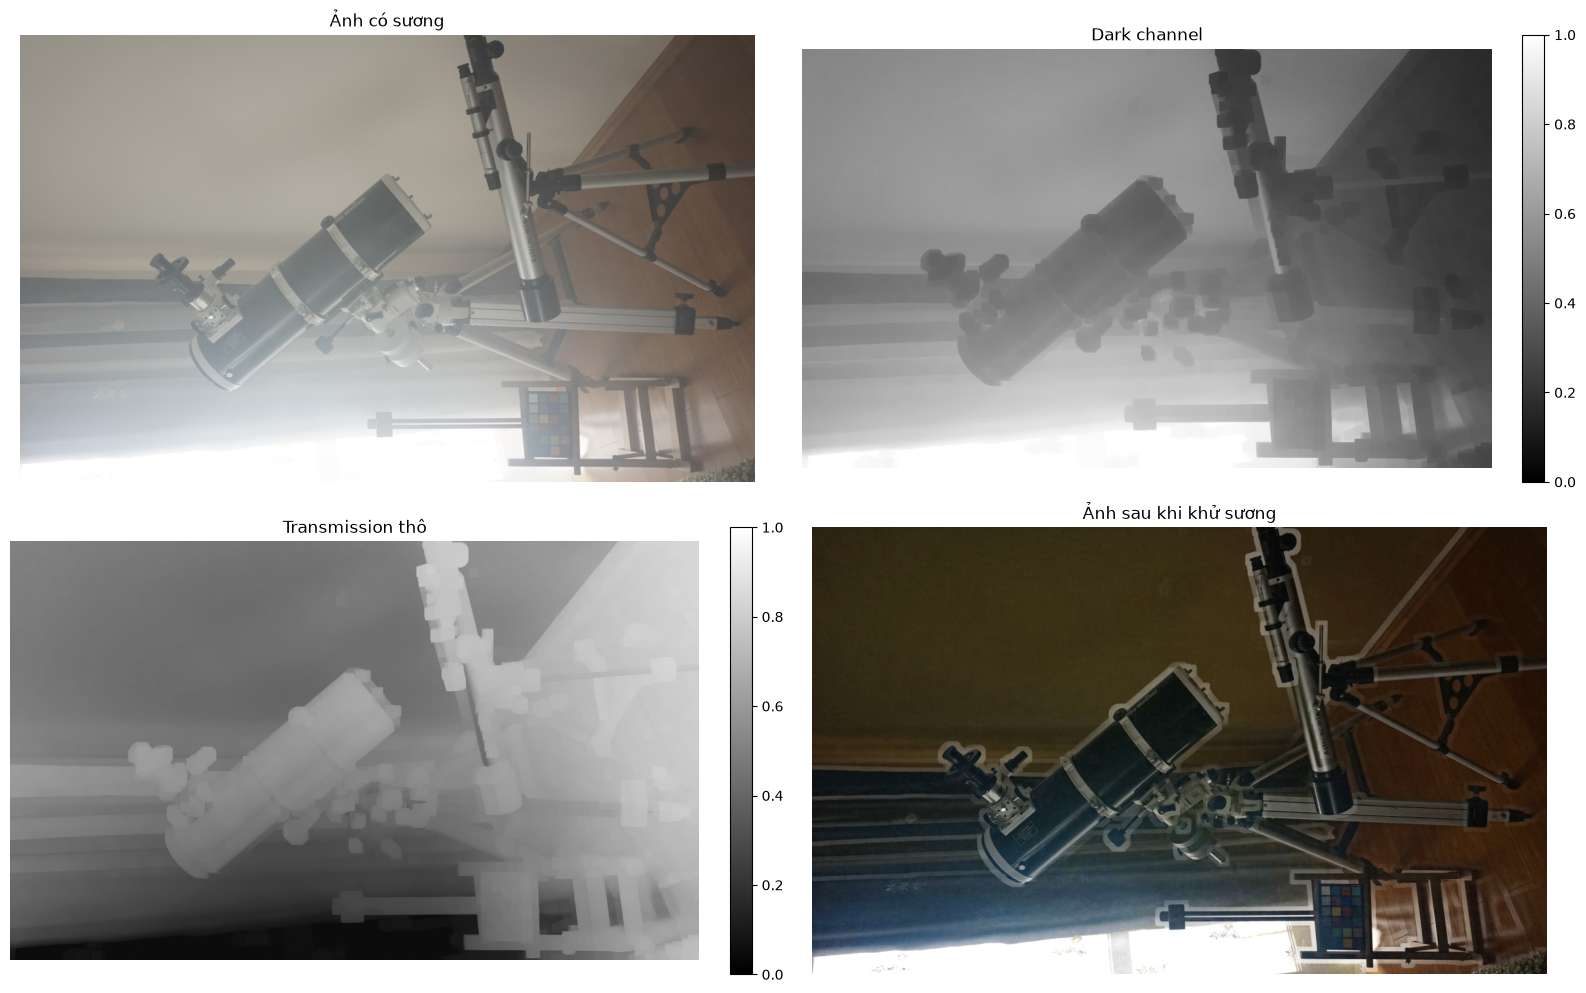

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(image)
axes[0, 0].set_title('Ảnh có sương')

dark_plot = axes[0, 1].imshow(dark, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Dark channel')
fig.colorbar(dark_plot, ax=axes[0, 1], fraction=0.046, pad=0.04)

transmission_plot = axes[1, 0].imshow(transmission, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Transmission thô')
fig.colorbar(transmission_plot, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(dehazed)
axes[1, 1].set_title('Ảnh sau khi khử sương')

for axis in axes.ravel():
    axis.axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Lưu ảnh kết quả ở cạnh notebook (bỏ comment nếu cần).
# output_path = Path('ih1_dehazed_dcp.png')
# output_bgr = cv2.cvtColor((dehazed * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
# cv2.imwrite(str(output_path), output_bgr)
# print(f'Đã lưu kết quả tại: {output_path.resolve()}')

## Refine transmission bằng Guided Filter

Transmission thô từ min-filter thường bị halo ở biên vật thể. Guided Filter dùng ảnh gốc làm ảnh hướng dẫn để làm mượt transmission nhưng vẫn giữ biên.

In [20]:
def guided_filter(guide, source, radius=40, eps=1e-3):
    """Guided Filter cho ảnh hướng dẫn và ảnh đầu vào một kênh trong [0, 1]."""
    guide = guide.astype(np.float32)
    source = source.astype(np.float32)
    kernel_size = (2 * radius + 1, 2 * radius + 1)

    mean_guide = cv2.boxFilter(guide, -1, kernel_size, borderType=cv2.BORDER_REFLECT)
    mean_source = cv2.boxFilter(source, -1, kernel_size, borderType=cv2.BORDER_REFLECT)
    mean_guide_source = cv2.boxFilter(
        guide * source, -1, kernel_size, borderType=cv2.BORDER_REFLECT
    )
    mean_guide_squared = cv2.boxFilter(
        guide * guide, -1, kernel_size, borderType=cv2.BORDER_REFLECT
    )

    covariance = mean_guide_source - mean_guide * mean_source
    variance = mean_guide_squared - mean_guide * mean_guide

    coefficient_a = covariance / (variance + eps)
    coefficient_b = mean_source - coefficient_a * mean_guide

    mean_a = cv2.boxFilter(
        coefficient_a, -1, kernel_size, borderType=cv2.BORDER_REFLECT
    )
    mean_b = cv2.boxFilter(
        coefficient_b, -1, kernel_size, borderType=cv2.BORDER_REFLECT
    )

    filtered = mean_a * guide + mean_b
    return np.clip(filtered, 0.0, 1.0)


# Dùng ảnh xám từ ảnh có sương làm guide để bảo toàn biên vật thể.
guide_gray = cv2.cvtColor(image.astype(np.float32), cv2.COLOR_RGB2GRAY)
transmission_refined = guided_filter(
    guide_gray,
    transmission,
    radius=40,
    eps=1e-3,
)

dehazed_guided = recover_scene_radiance(
    image,
    transmission_refined,
    atmospheric_light,
    t0=t0,
)

print(
    f'Transmission sau Guided Filter: min={transmission_refined.min():.4f}, '
    f'max={transmission_refined.max():.4f}, '
    f'mean={transmission_refined.mean():.4f}'
)

Transmission sau Guided Filter: min=0.0542, max=0.8354, mean=0.4910


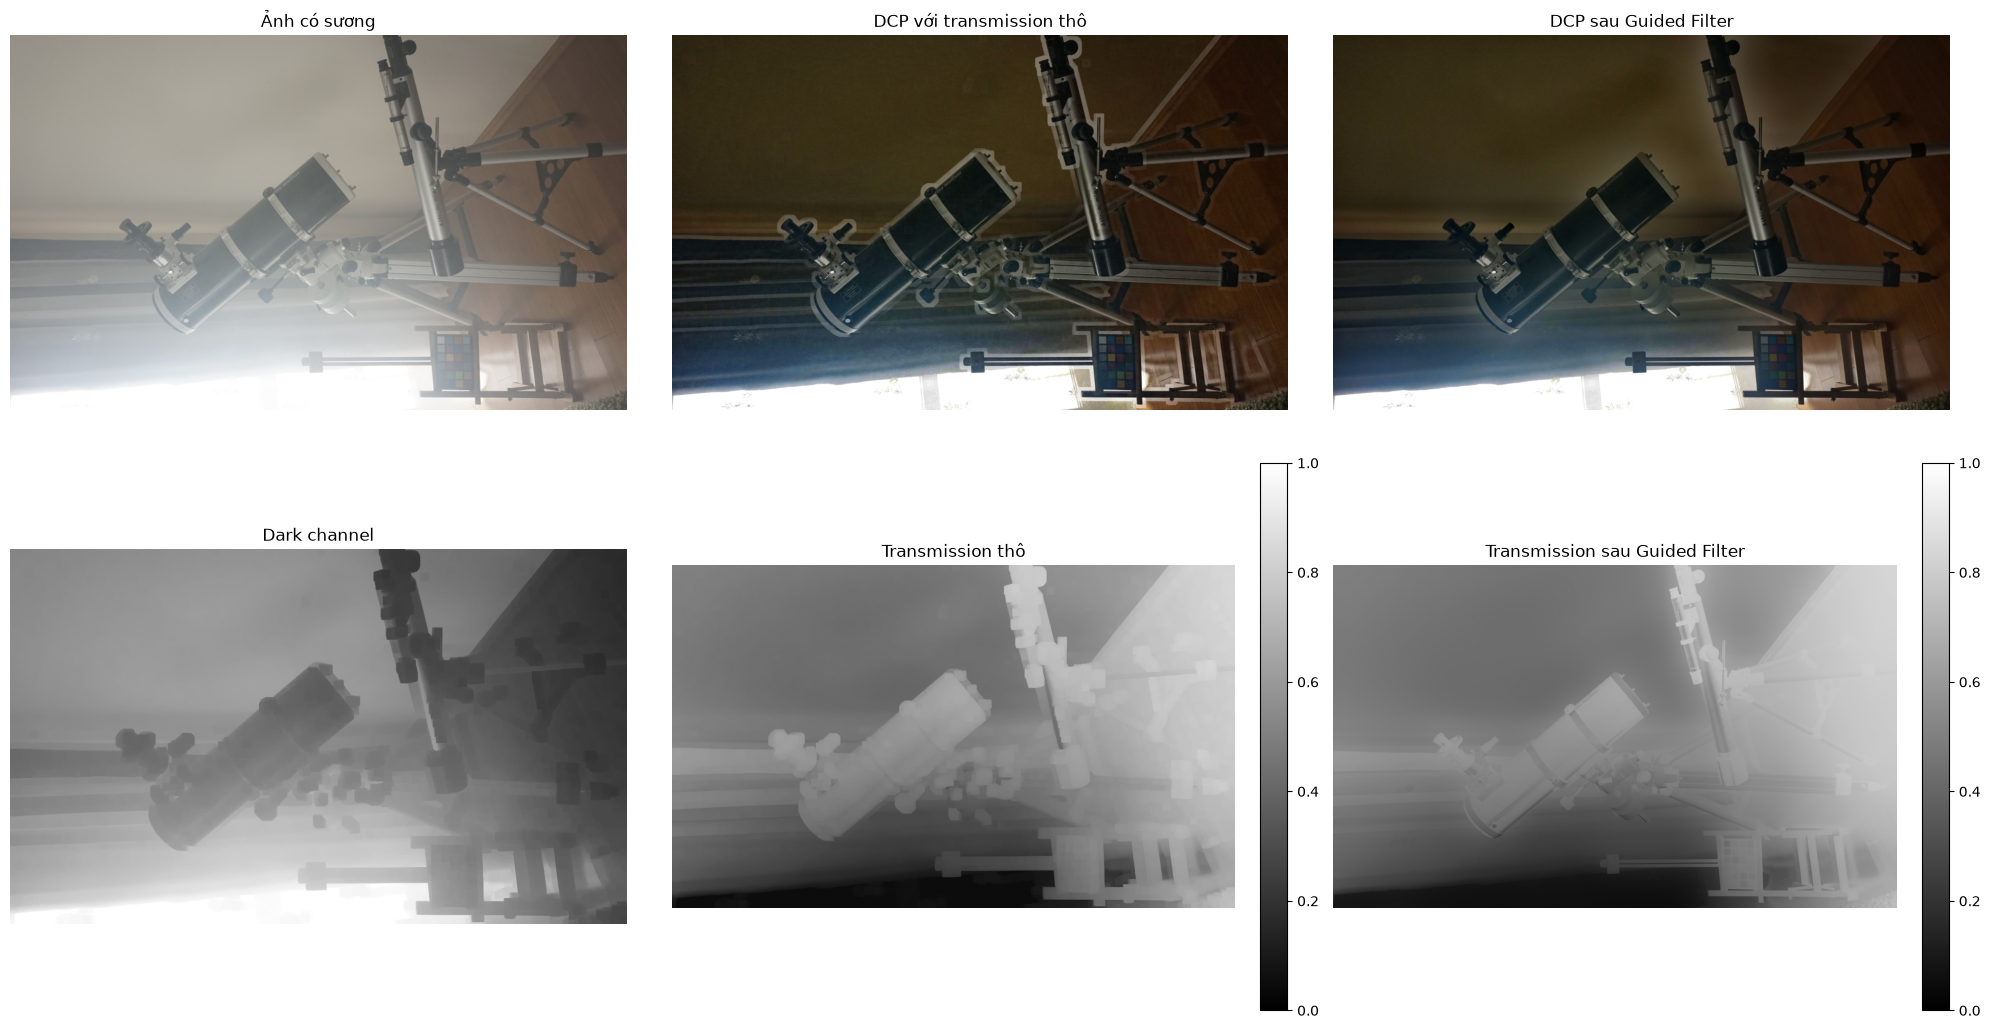

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0, 0].imshow(image)
axes[0, 0].set_title('Ảnh có sương')

axes[0, 1].imshow(dehazed)
axes[0, 1].set_title('DCP với transmission thô')

axes[0, 2].imshow(dehazed_guided)
axes[0, 2].set_title('DCP sau Guided Filter')

axes[1, 0].imshow(dark, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Dark channel')

raw_plot = axes[1, 1].imshow(transmission, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title('Transmission thô')
fig.colorbar(raw_plot, ax=axes[1, 1], fraction=0.046, pad=0.04)

refined_plot = axes[1, 2].imshow(
    transmission_refined, cmap='gray', vmin=0, vmax=1
)
axes[1, 2].set_title('Transmission sau Guided Filter')
fig.colorbar(refined_plot, ax=axes[1, 2], fraction=0.046, pad=0.04)

for axis in axes.ravel():
    axis.axis('off')

plt.tight_layout()
plt.show()

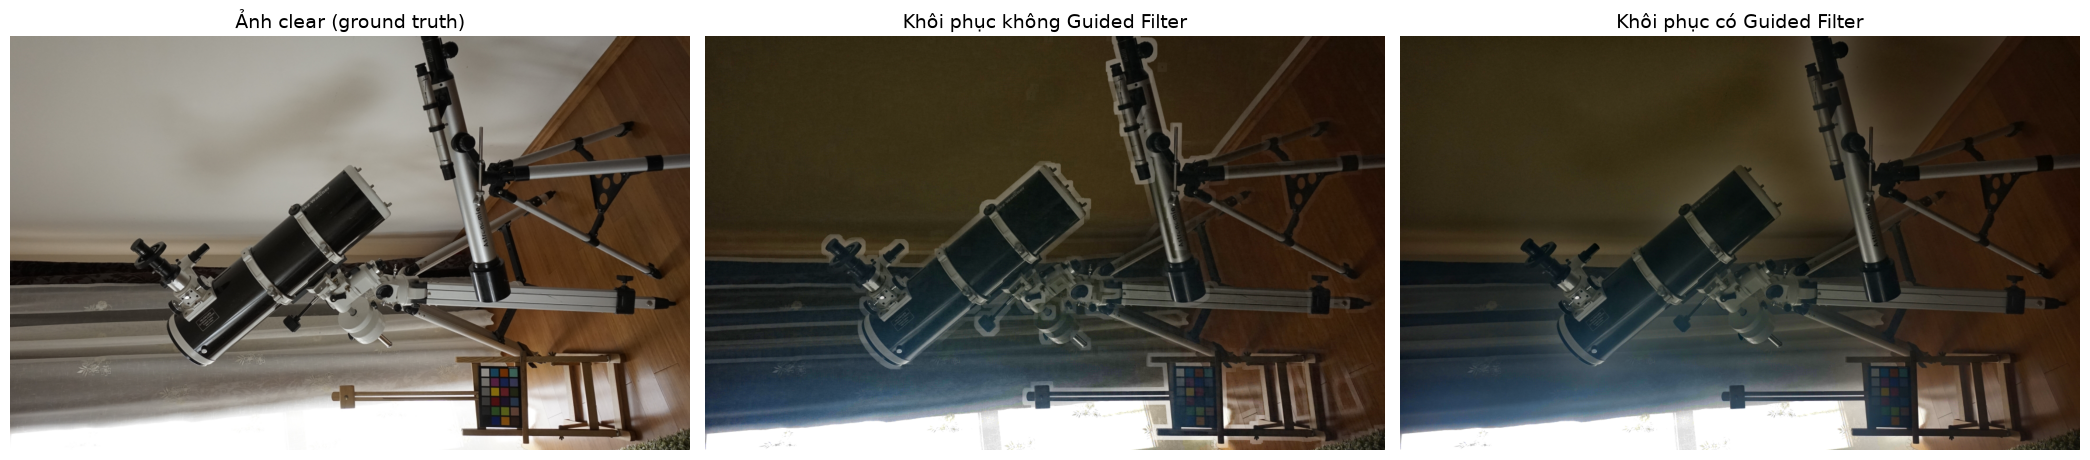

In [22]:
# So sánh ảnh clear (ground truth) và hai kết quả khôi phục.
clear_candidates = [
    Path('../dataset/I-HAZE/train/clear/ih1.png'),
    Path('dataset/I-HAZE/train/clear/ih1.png'),
]
clear_path = next((path for path in clear_candidates if path.exists()), None)
if clear_path is None:
    raise FileNotFoundError('Không tìm thấy ảnh clear ih1.png trong dataset.')

clear_bgr = cv2.imread(str(clear_path))
if clear_bgr is None:
    raise ValueError(f'Không thể đọc ảnh clear: {clear_path}')

clear_rgb = cv2.cvtColor(clear_bgr, cv2.COLOR_BGR2RGB)
clear_image = clear_rgb.astype(np.float64) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

comparison_images = [clear_image, dehazed, dehazed_guided]
comparison_titles = [
    'Ảnh clear (ground truth)',
    'Khôi phục không Guided Filter',
    'Khôi phục có Guided Filter',
]

for axis, comparison_image, title in zip(
    axes, comparison_images, comparison_titles
):
    axis.imshow(comparison_image)
    axis.set_title(title, fontsize=14)
    axis.axis('off')

plt.tight_layout()
plt.show()